C:\Users\yerayhurdra\AppData\Local\Temp\ipykernel_6296\3145579567.py:50: DtypeWarning: Columns (112) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../data/processed/final_dataset_cleaned.csv')


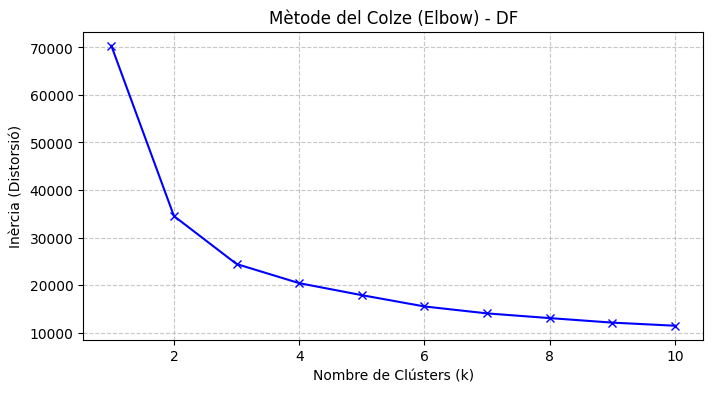

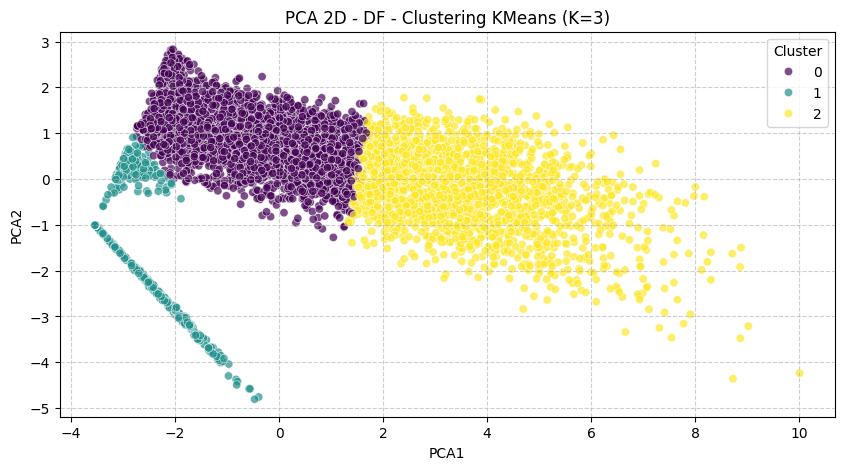

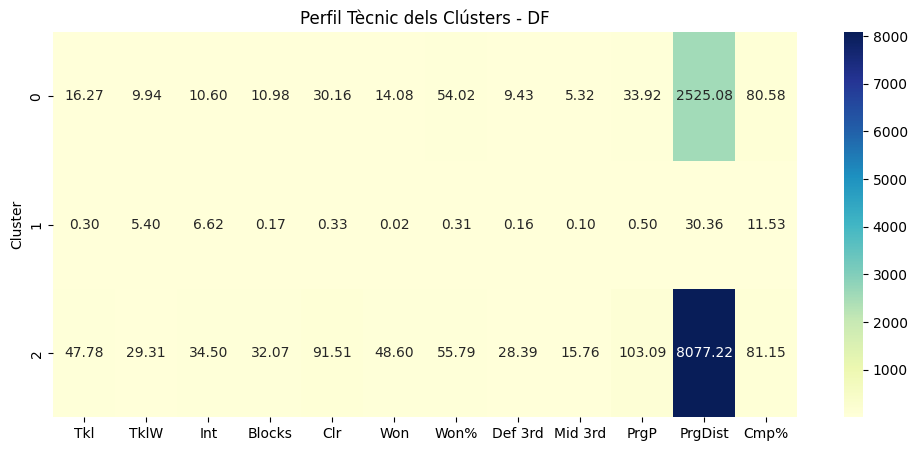

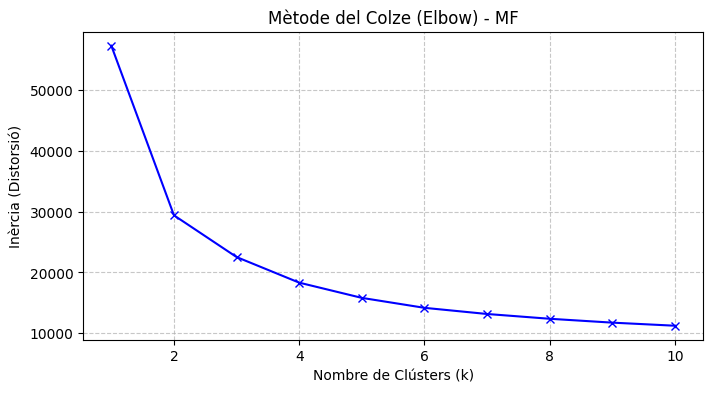

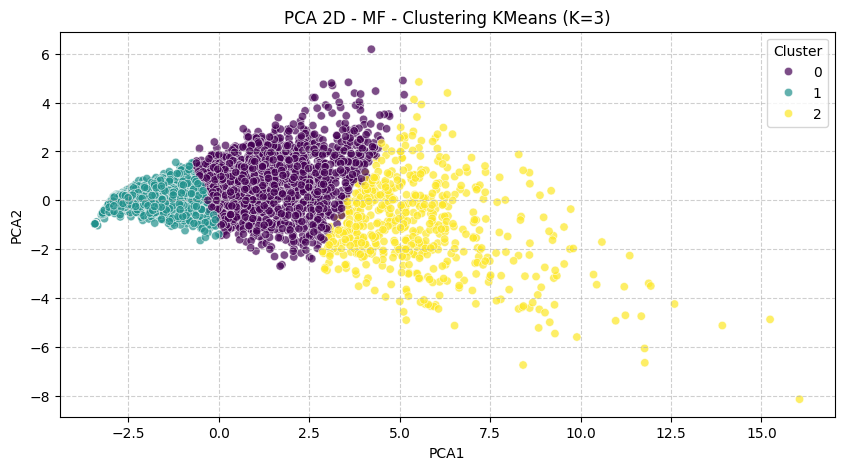

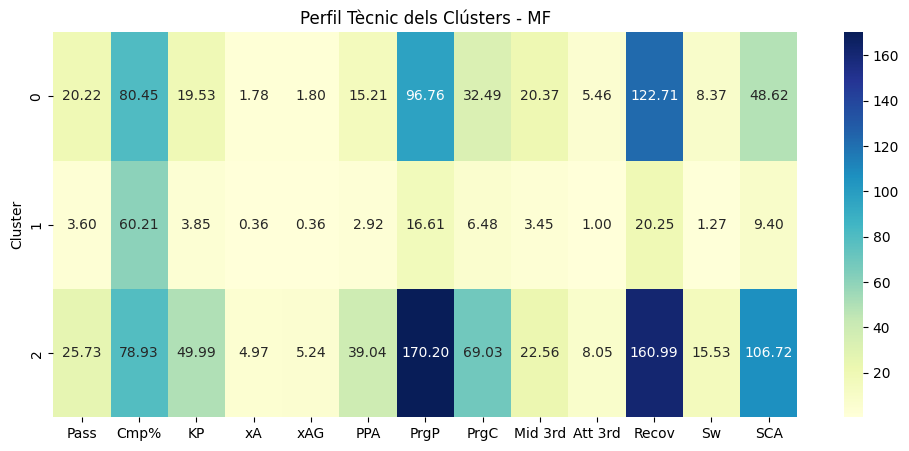

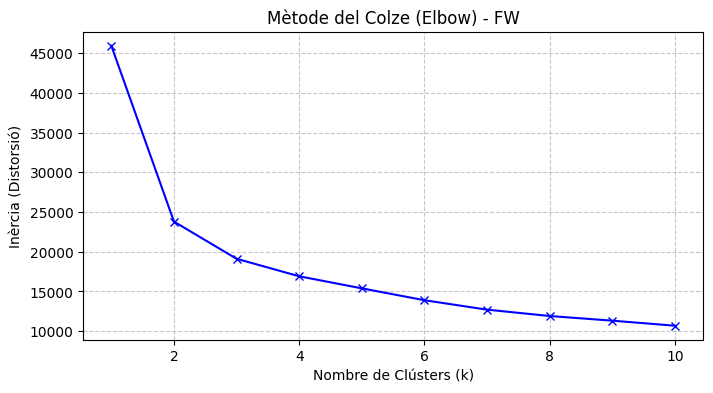

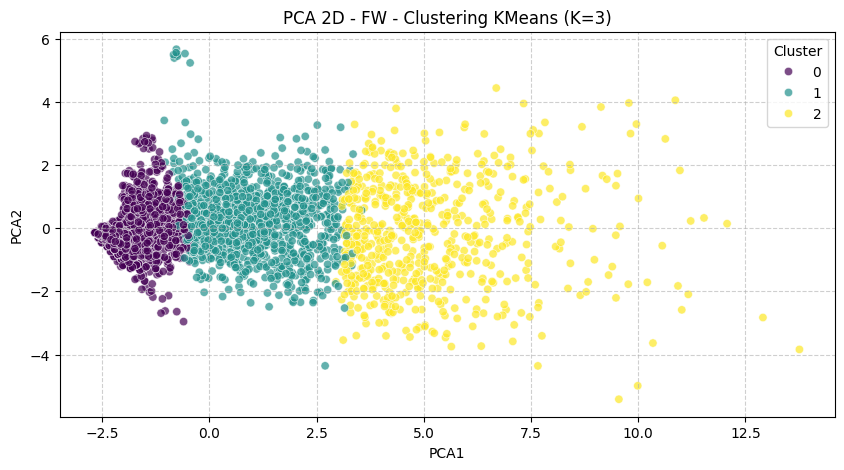

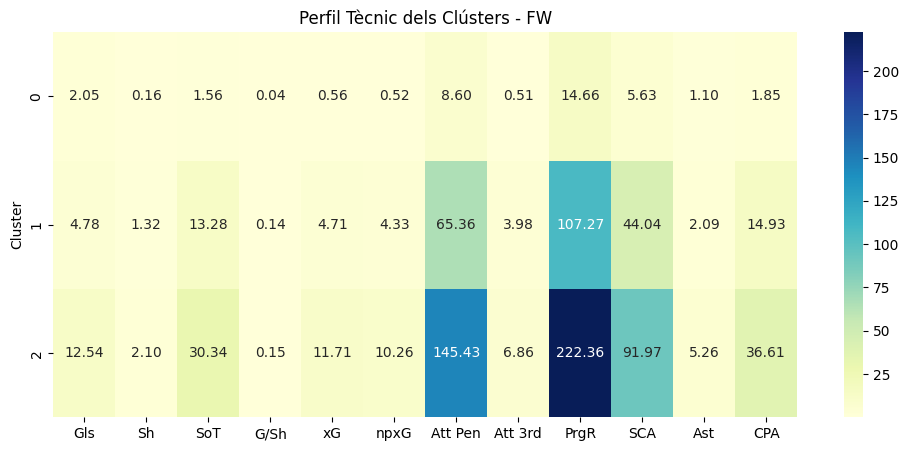

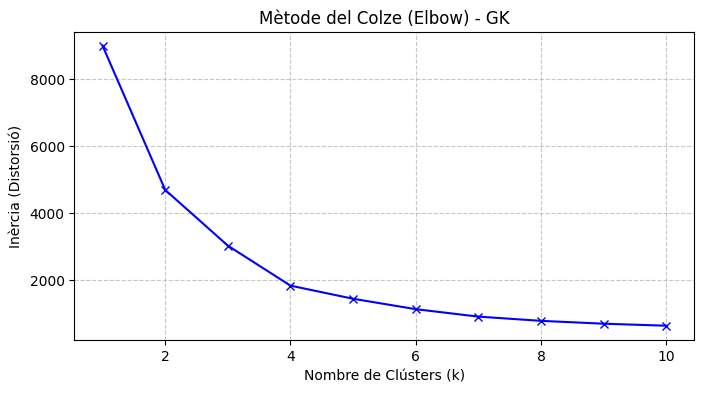

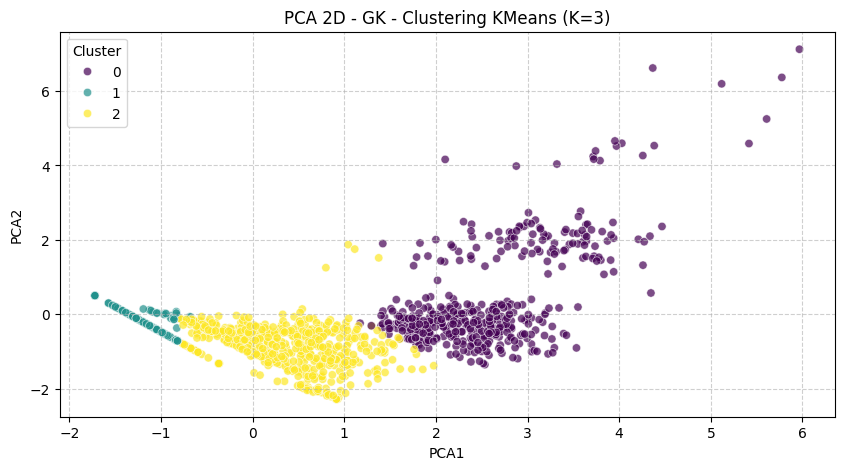

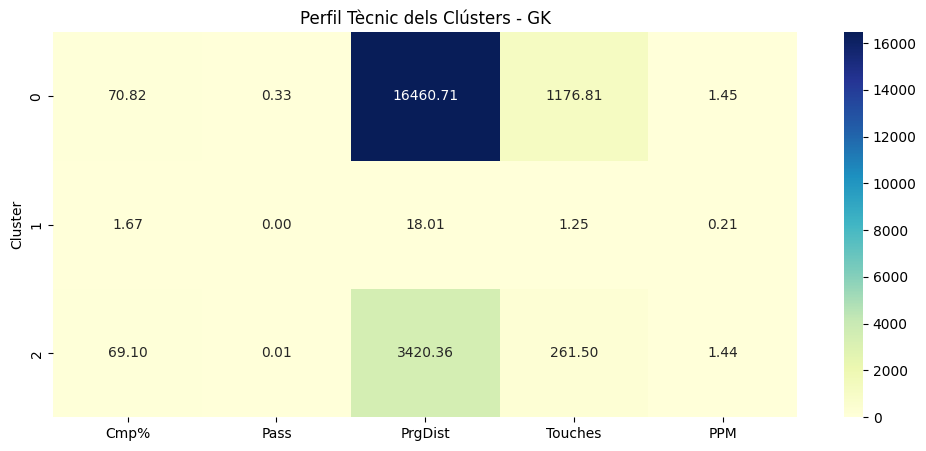


RESUM GLOBAL DE RENDIMENT:
  Posició  K-escollida  Silhouette  Calinski-Harabasz  Davies-Bouldin
0      DF            3    0.423506        5507.501514        0.892576
1      MF            3    0.384089        3403.501978        1.168093
2      FW            3    0.376865        2685.216104        1.223494
3      GK            3    0.554834        1770.188136        0.908540


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. Configuració de mètriques per posició
FEATURES_BY_POS = {
    'df': ['Tkl', 'TklW', 'Int', 'Blocks', 'Clr', 'Won', 'Won%', 'Def 3rd', 'Mid 3rd', 'PrgP', 'PrgDist', 'Cmp%'],
    'mf': ['Pass', 'Cmp%', 'KP', 'xA', 'xAG', 'PPA', 'PrgP', 'PrgC', 'Mid 3rd', 'Att 3rd', 'Recov', 'Sw', 'SCA'],
    'fw': ['Gls', 'Sh', 'SoT', 'G/Sh', 'xG', 'npxG', 'Att Pen', 'Att 3rd', 'PrgR', 'SCA', 'Ast', 'CPA'],
    'gk': ['Cmp%', 'Pass', 'PrgDist', 'Touches', 'PPM']
}

def plot_elbow_method(X_scaled, pos):
    """Calcula i dibuixa el mètode del colze per trobar la K òptima."""
    inertia = []
    k_range = range(1, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)
    
    plt.figure(figsize=(8, 4))
    plt.plot(k_range, inertia, 'bx-')
    plt.xlabel('Nombre de Clústers (k)')
    plt.ylabel('Inèrcia (Distorsió)')
    plt.title(f'Mètode del Colze (Elbow) - {pos.upper()}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def plot_pca(df, pos, title, cluster_col=None):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x='PCA1', y='PCA2', hue=cluster_col, palette='viridis' if cluster_col else None, alpha=0.7)
    plt.title(f"PCA 2D - {pos.upper()} - {title}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def evaluate_clusters(X_scaled, cluster_labels):
    sil = silhouette_score(X_scaled, cluster_labels)
    ch = calinski_harabasz_score(X_scaled, cluster_labels)
    db = davies_bouldin_score(X_scaled, cluster_labels)
    return sil, ch, db

# --- Procés principal ---

df_raw = pd.read_csv('../data/processed/final_dataset_cleaned.csv') 
df_raw['Pos_Main'] = df_raw['Pos'].str.split(',').str[0].str.lower()

results_summary = []

for pos, metrics in FEATURES_BY_POS.items():
    pos_df = df_raw[df_raw['Pos_Main'] == pos].copy()
    if len(pos_df) < 15: continue 

    # Preprocessament
    X = pos_df[metrics].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # A. EXECUTAR MÈTODE DEL COLZE (Visualització per decidir K)
    plot_elbow_method(X_scaled, pos)

    # B. PCA per visualització
    pca = PCA(n_components=3)
    pca_res = pca.fit_transform(X_scaled)
    pos_df['PCA1'], pos_df['PCA2'], pos_df['PCA3'] = pca_res[:,0], pca_res[:,1], pca_res[:,2]

    # C. Aplicar KMeans 
    # Pots canviar n_clusters segons el que hagis vist al gràfic del colze
    n_clusters = 3 
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    pos_df['Cluster'] = kmeans.fit_predict(X_scaled)

    # D. AVALUACIÓ
    sil, ch, db = evaluate_clusters(X_scaled, pos_df['Cluster'])
    results_summary.append({
        'Posició': pos.upper(),
        'K-escollida': n_clusters,
        'Silhouette': sil,
        'Calinski-Harabasz': ch,
        'Davies-Bouldin': db
    })

    # E. VISUALITZACIÓ I PERFILS
    plot_pca(pos_df, pos, f"Clustering KMeans (K={n_clusters})", cluster_col='Cluster')
    
    cluster_profile = pos_df.groupby('Cluster')[metrics].mean()
    plt.figure(figsize=(12, 5))
    sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title(f"Perfil Tècnic dels Clústers - {pos.upper()}")
    plt.show()

df_metrics = pd.DataFrame(results_summary)
print("\nRESUM GLOBAL DE RENDIMENT:")
print(df_metrics)